# **Microproyecto 1 - Tecnicas de Deep Learning**
**Clasificación de MRI con Redes Neuronales Convolucionales para Tipos de Cáncer usando Modelo Fundacional Resnet del framework MONIA (Medical Open Network AI)**

Omar Diaz / Diego Burbano

### 1. Importacion de Librerias

In [ ]:
!pip install -q kagglehub monai torch torchvision torchaudio

import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import kagglehub # Para descargar el dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Importación de librerías MONAI
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    ResizeWithPadOrCropd,
    ToTensorD,
    RandFlipd,
    RandRotate90d,
    RandZoomd,
    RandLambdaD
)
from monai.data import Dataset, DataLoader
from monai.networks.nets import resnet18
from monai.utils import set_determinism

# Importación de Grayscale de Torchvision
from torchvision.transforms import Grayscale

# Fijar semilla para reproducibilidad
set_determinism(seed=42)

# Definir dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo usado: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 75.5 MB/s eta 0:00:00
Dispositivo usado: cuda


### 2. Importacion de Imágenes

In [ ]:
# Descargar el dataset
path = kagglehub.dataset_download("rm1000/brain-tumor-mri-scans")
print("Dataset descargado en:", path)


Using Colab cache for faster access to the 'brain-tumor-mri-scans' dataset.
Dataset descargado en: /kaggle/input/brain-tumor-mri-scans


In [ ]:
# Inspeccionar el primer nivel de carpetas
for root, dirs, files in os.walk(path):
    print("Subcarpetas:", dirs)
    break


Subcarpetas: ['pituitary', 'healthy', 'meningioma', 'glioma']


In [ ]:
# Carga de datos en las variables X y Y
X = []
Y = []

# Recorrer todas las carpetas dentro de la ruta base
for class_name in os.listdir(path):
    class_path = os.path.join(path, class_name)

    # Validar que sea una carpeta (no un archivo)
    if os.path.isdir(class_path):
        # Recorrer todas las imágenes dentro de esa carpeta
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            # Guardar la ruta en X y la etiqueta (nombre de la carpeta) en Y
            X.append(img_path)
            Y.append(class_name)

In [ ]:
#Verificar que se hayan cargado correctamente los datos y sus etiquetas
indices = random.sample(range(0, 7023), 10)
for i in indices:
  print(f"Imagen: {X[i]}  -->  Etiqueta: {Y[i]}")

Imagen: /kaggle/input/brain-tumor-mri-scans/meningioma/1229.jpg  -->  Etiqueta: meningioma
Imagen: /kaggle/input/brain-tumor-mri-scans/pituitary/0309.jpg  -->  Etiqueta: pituitary
Imagen: /kaggle/input/brain-tumor-mri-scans/pituitary/1648.jpg  -->  Etiqueta: pituitary
Imagen: /kaggle/input/brain-tumor-mri-scans/glioma/0832.jpg  -->  Etiqueta: glioma
Imagen: /kaggle/input/brain-tumor-mri-scans/healthy/1904.jpg  -->  Etiqueta: healthy
Imagen: /kaggle/input/brain-tumor-mri-scans/healthy/0729.jpg  -->  Etiqueta: healthy
Imagen: /kaggle/input/brain-tumor-mri-scans/healthy/0680.jpg  -->  Etiqueta: healthy
Imagen: /kaggle/input/brain-tumor-mri-scans/pituitary/1000.jpg  -->  Etiqueta: pituitary
Imagen: /kaggle/input/brain-tumor-mri-scans/glioma/0636.jpg  -->  Etiqueta: glioma
Imagen: /kaggle/input/brain-tumor-mri-scans/pituitary/0842.jpg  -->  Etiqueta: pituitary


In [ ]:
#Verificación de balanceo de clases
pd.Series(Y).value_counts()

,count
healthy,2000
pituitary,1757
meningioma,1645
glioma,1621


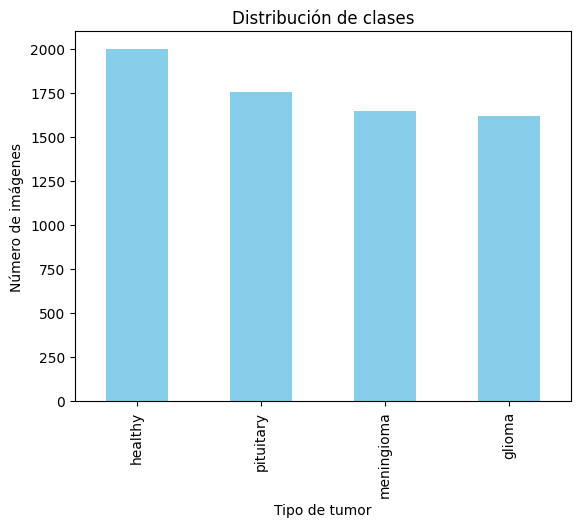

In [ ]:
pd.Series(Y).value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribución de clases")
plt.xlabel("Tipo de tumor")
plt.ylabel("Número de imágenes")
plt.show()

### 3. Transformación de las imágenes, creación de los set de entrenamiento y prueba y preparación de los Tensores para el modelo

In [ ]:
# Codificación de etiquetas
label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)
class_names = list(label_encoder.classes_)
num_classes = len(class_names)
print(f"Clases codificadas: {list(zip(class_names, label_encoder.transform(class_names)))}")
print(f"Número total de clases: {num_classes}")

# Creación de la lista de diccionarios para MONAI
data = [{"image": x, "label": y} for x, y in zip(X, Y_encoded)]


Clases codificadas: [(np.str_('glioma'), np.int64(0)), (np.str_('healthy'), np.int64(1)), (np.str_('meningioma'), np.int64(2)), (np.str_('pituitary'), np.int64(3))]
Número total de clases: 4


In [ ]:
from sklearn.model_selection import train_test_split

# train_data tendrá el 70% (Entrenamiento)
# temp_data tendrá el 30% (Datos temporales para Validación y Test)
train_data, temp_data = train_test_split(
    data,
    test_size=0.3,                 # 30% de 'data'
    stratify=Y_encoded,            # Usar etiquetas originales para estratificar
    random_state=42
)

val_labels = [d['label'] for d in temp_data]

val_data, test_data = train_test_split(
    temp_data,
    test_size=1/3,
    stratify=val_labels,
    random_state=42
)

print(f"Imágenes de entrenamiento: {len(train_data)}")
print(f"Imágenes de validación: {len(val_data)}")
print(f"Imágenes de prueba: {len(test_data)}")

Imágenes de entrenamiento: 4916
Imágenes de validación: 1404
Imágenes de prueba: 703


In [ ]:
# Función para convertir un arreglo NumPy RGB [H, W, 3] a Grayscale [H, W, 1]
def numpy_grayscale_transform(img):
    """Aplica la conversión a escala de grises (luminosidad) a un arreglo NumPy."""
    # img es un NumPy array cargado por LoadImaged
    if img.ndim == 3 and img.shape[-1] == 3:
        gray_img = np.dot(img[...,:3], [0.2989, 0.5870, 0.1140])
        # Aseguramos que la dimensión del canal [H, W, 1] se mantenga para MONAI
        return np.expand_dims(gray_img, axis=-1)
    # Si ya es un canal único, lo devolvemos
    return img

In [ ]:
# Tamaño estándar de entrada para DenseNet/ResNet (224x224 para 2D)
IMG_SIZE = 150
BATCH_SIZE = 8

# Definición de la pipeline de transformaciones (corregida)
base_transforms = [
    LoadImaged(keys=["image"], image_only=True), # -> [H, W, 3] NumPy

    #Conversión a Grayscale y asegurar [H, W, 1] <===
    RandLambdaD(keys=["image"], func=numpy_grayscale_transform, prob=1.0),

    ScaleIntensityRanged(keys=["image"], a_min=0.0, a_max=255.0, b_min=0.0, b_max=1.0), # Normaliza [H, W, 1]

    #Asegurar canal primero [H, W, 1] -> [1, H, W] (Tensor)
    EnsureChannelFirstd(keys=["image"], channel_dim=2),

    # Redimensionar el tensor [1, H, W] (Aquí se resuelve el ValueError)
    ResizeWithPadOrCropd(keys=["image"], spatial_size=[IMG_SIZE, IMG_SIZE]),
]

# Transformaciones para Entrenamiento (añadir Aumento de Datos)
train_transforms = Compose(base_transforms + [
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1), # spatial_axis=1 es altura (H) en [C, H, W]
    RandRotate90d(keys=["image"], prob=0.5, max_k=3),
    RandZoomd(keys=["image"], prob=0.2, min_zoom=0.9, max_zoom=1.1, mode="bilinear"),
    ToTensorD(keys=["image", "label"]),
])

# Transformaciones para Validación/Prueba (solo preprocesamiento)
val_transforms = Compose(base_transforms + [
    ToTensorD(keys=["image", "label"]),
])

In [ ]:
# Creación de Datasets y DataLoaders
train_ds = Dataset(data=train_data, transform=train_transforms)
val_ds = Dataset(data=val_data, transform=val_transforms)
test_ds = Dataset(data=test_data, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Visualizando 8 imágenes con transformaciones MONAI (Grayscale) aplicadas:


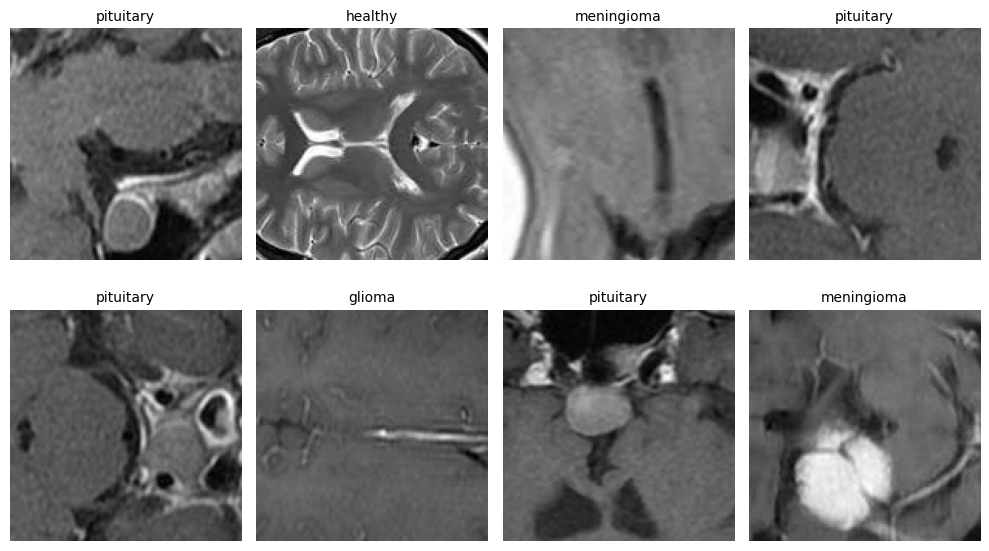

In [ ]:
print("\nVisualizando 8 imágenes con transformaciones MONAI (Grayscale) aplicadas:")

indices = random.sample(range(len(train_ds)), 8)
fig, axes = plt.subplots(2, 4, figsize=(10, 6))
axes = axes.flatten()

for i, idx in enumerate(indices):
    sample = train_ds[idx]

    img_t = sample['image']        # Tensor de la imagen: [1, 224, 224] (C, H, W)
    label_encoded = sample['label'].item()
    label_name = class_names[label_encoded]

    # Convertir tensor [1, H, W] a NumPy [H, W] para Matplotlib
    img_np = img_t.squeeze().cpu().numpy()

    axes[i].imshow(img_np, cmap='gray') # Usar 'gray' para Grayscale
    axes[i].set_title(label_name, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

###4. Construccion de la CNN

In [ ]:
model = resnet18(
    spatial_dims=2,  # Imágenes 2D
    n_input_channels=1, # Para Grayscale (1 canal)
    num_classes=num_classes
).to(device)

In [ ]:
# 4.2 Definir la Función de Pérdida y el Optimizador
loss_function = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), 1e-4)

In [ ]:
path = './models_output'
if not os.path.exists(path):
    os.makedirs(path)
max_epochs = 10
val_interval = 1
best_metric = -1
best_metric_epoch = -1

# ===> LISTAS PARA ALMACENAR DATOS DE LA GRÁFICA <===
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []

print("\n" + "="*60)
print(f"INICIANDO ENTRENAMIENTO (LR ajustado): MAX_EPOCHS={max_epochs}, LR={optimizer.param_groups[0]['lr']}")
print("============================================================")

for epoch in range(max_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    # Bucle de Entrenamiento
    for batch_data in train_loader:
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ALMACENAR MÉTRICAS DE ENTRENAMIENTO
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc * 100)

    # Bucle de Validación
    if (epoch + 1) % val_interval == 0:
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for val_data in val_loader:
                val_images, val_labels = val_data["image"].to(device), val_data["label"].to(device)
                val_outputs = model(val_images)

                loss = loss_function(val_outputs, val_labels)
                val_loss += loss.item() * val_images.size(0)

                _, predicted = torch.max(val_outputs.data, 1)
                val_total += val_labels.size(0)
                val_correct += (predicted == val_labels).sum().item()

        val_loss /= val_total
        val_acc = val_correct / val_total

        # ALMACENAR MÉTRICAS DE VALIDACIÓN
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc * 100)

        # Guardar el mejor modelo
        if val_acc > best_metric:
            best_metric = val_acc
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), os.path.join(path, "best_metric_model.pth"))
            best_model_saved = " (Guardado)"
        else:
            best_model_saved = ""

        # Impresión de la época
        print(f"Epoch [{epoch + 1}/{max_epochs}] | T_Loss: {train_loss:.4f} | T_Acc: {train_acc*100:.2f}% | V_Loss: {val_loss:.4f} | V_Acc: {val_acc*100:.2f}%{best_model_saved}")

print(f"\nEntrenamiento finalizado. Mejor precisión en validación: {best_metric*100:.2f}% en la época {best_metric_epoch}")


INICIANDO ENTRENAMIENTO (LR ajustado): MAX_EPOCHS=10, LR=0.0001
Epoch [1/10] | T_Loss: 0.6136 | T_Acc: 77.71% | V_Loss: 1.5151 | V_Acc: 64.25% (Guardado)
Epoch [2/10] | T_Loss: 0.5394 | T_Acc: 80.21% | V_Loss: 0.5689 | V_Acc: 80.77% (Guardado)
Epoch [3/10] | T_Loss: 0.5001 | T_Acc: 81.86% | V_Loss: 1.0424 | V_Acc: 68.66%
Epoch [4/10] | T_Loss: 0.4502 | T_Acc: 83.36% | V_Loss: 0.4881 | V_Acc: 81.55% (Guardado)
Epoch [5/10] | T_Loss: 0.4335 | T_Acc: 83.50% | V_Loss: 0.4453 | V_Acc: 83.12% (Guardado)
Epoch [6/10] | T_Loss: 0.4132 | T_Acc: 84.48% | V_Loss: 0.7986 | V_Acc: 73.93%
Epoch [7/10] | T_Loss: 0.3670 | T_Acc: 86.53% | V_Loss: 0.3784 | V_Acc: 86.68% (Guardado)
Epoch [8/10] | T_Loss: 0.3708 | T_Acc: 86.43% | V_Loss: 0.3005 | V_Acc: 89.67% (Guardado)
Epoch [9/10] | T_Loss: 0.3500 | T_Acc: 87.21% | V_Loss: 0.2869 | V_Acc: 89.46%
Epoch [10/10] | T_Loss: 0.3369 | T_Acc: 87.69% | V_Loss: 0.3182 | V_Acc: 87.82%

Entrenamiento finalizado. Mejor precisión en validación: 89.67% en la época 8


GENERANDO GRÁFICAS DE EVOLUCIÓN (ENTRENAMIENTO vs VALIDACIÓN)


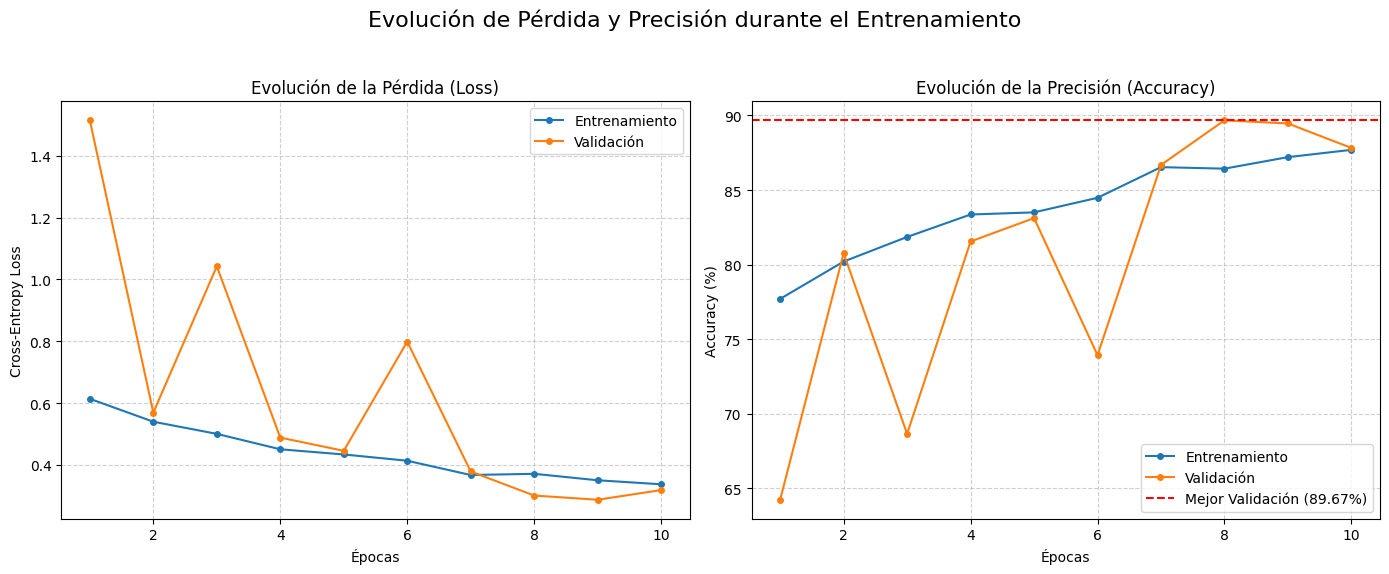

In [ ]:
print("\n" + "="*50)
print("GENERANDO GRÁFICAS DE EVOLUCIÓN (ENTRENAMIENTO vs VALIDACIÓN)")
print("="*50)

# Crear rango de épocas
epochs = range(1, max_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Evolución de Pérdida y Precisión durante el Entrenamiento", fontsize=16)

# Gráfica 1: Pérdida (Loss)
axes[0].plot(epochs, train_loss_history, label="Entrenamiento", marker='o', markersize=4)
axes[0].plot(epochs, val_loss_history, label="Validación", marker='o', markersize=4)
axes[0].set_title("Evolución de la Pérdida (Loss)")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Gráfica 2: Accuracy (Precisión)
axes[1].plot(epochs, train_acc_history, label="Entrenamiento", marker='o', markersize=4)
axes[1].plot(epochs, val_acc_history, label="Validación", marker='o', markersize=4)
axes[1].set_title("Evolución de la Precisión (Accuracy)")
axes[1].set_xlabel("Épocas")
axes[1].set_ylabel("Accuracy (%)")
axes[1].axhline(y=best_metric * 100, color='r', linestyle='--', label=f'Mejor Validación ({best_metric*100:.2f}%)')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA (MEJOR MODELO ÉPOCA 8)
Precisión Final en el Conjunto de Prueba: 90.61%

Reporte de Clasificación:

              precision    recall  f1-score   support

      glioma       0.98      0.84      0.90       162
     healthy       0.98      0.89      0.93       200
  meningioma       0.74      0.98      0.84       165
   pituitary       0.99      0.92      0.95       176

    accuracy                           0.91       703
   macro avg       0.92      0.91      0.91       703
weighted avg       0.93      0.91      0.91       703



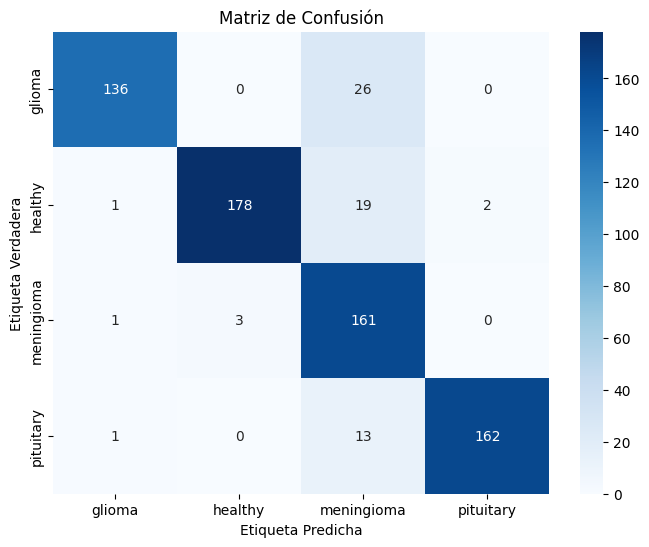

In [ ]:
# ==============================================================================
# 6. EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA (TEST) Y MATRIZ DE CONFUSIÓN
# ==============================================================================

print("\n" + "="*50)
print(f"EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA (MEJOR MODELO ÉPOCA {best_metric_epoch})")
print("="*50)

# Cargar el mejor modelo guardado (el que mejor desempeño tuvo en Validación)
best_model_path = os.path.join(path, "best_metric_model.pth")
model.load_state_dict(torch.load(best_model_path))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = test_data["image"].to(device), test_data["label"].to(device)
        test_outputs = model(test_images)

        _, predicted = torch.max(test_outputs.data, 1)

        y_true.extend(test_labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Generar métricas finales
final_test_acc = (np.array(y_true) == np.array(y_pred)).sum() / len(y_true)
print(f"Precisión Final en el Conjunto de Prueba: {final_test_acc*100:.2f}%")

# Reporte de Clasificación (Precisión, Recall, F1-score)
class_names_list = list(label_encoder.classes_)
print("\nReporte de Clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names_list))

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()